In [1]:
import scanpy as sc
import numpy as np
import anndata as ad

In [2]:
import anndata as ad

In [3]:
import seaborn as sns
import matplotlib.pyplot as plt

In [4]:
import pandas as pd

In [5]:
from scipy.stats import kruskal
from statsmodels.stats.multitest import multipletests

In [6]:
import matplotlib.pyplot as plt
plt.rcParams.update(plt.rcParamsDefault)


In [7]:
import matplotlib
matplotlib.rcParams['pdf.fonttype'] = 42

In [8]:
def get_path(training_split, run, output_name = 'global'):
    base_path = 'tripso_reproducibility/04.4_HSC_fix_hvg'
    return f'{base_path}/{run}_by_study/output_{output_name}/ablation/with_gp_ablation/{training_split}_set.h5ad'

In [9]:
train1 = sc.read_h5ad(get_path('train', 'run_1'))
train1 = train1[train1.obs['study'] == 'Isobe_CD34']

val1 = sc.read_h5ad(get_path('val', 'run_1'))
val1 = val1[val1.obs['study'] == 'Isobe_CD34']

test1 = sc.read_h5ad(get_path('test', 'run_1'))
test1 = test1[test1.obs['study'] == 'Isobe_CD34']

pert_data1 = ad.concat([train1, val1, test1])

/software/cellgen/team292/mm58/venvs/lightning2/lib/python3.10/site-packages/anndata/_core/anndata.py:1754: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  utils.warn_names_duplicates("obs")
/software/cellgen/team292/mm58/venvs/lightning2/lib/python3.10/site-packages/anndata/_core/anndata.py:1754: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  utils.warn_names_duplicates("obs")
/software/cellgen/team292/mm58/venvs/lightning2/lib/python3.10/site-packages/anndata/_core/anndata.py:1754: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  utils.warn_names_duplicates("obs")
/software/cellgen/team292/mm58/venvs/lightning2/lib/python3.10/site-packages/anndata/_core/anndata.py:1754: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  utils.warn_names_duplicates("obs")


In [10]:
train2 = sc.read_h5ad(get_path('train', 'run_2'))
train2 = train2[train2.obs['study'] == 'Isobe_CD34']

val2 = sc.read_h5ad(get_path('val', 'run_2'))
val2 = val2[val2.obs['study'] == 'Isobe_CD34']

test2 = sc.read_h5ad(get_path('test', 'run_2'))
test2 = test2[test2.obs['study'] == 'Isobe_CD34']

pert_data2 = ad.concat([train2, val2, test2])

/software/cellgen/team292/mm58/venvs/lightning2/lib/python3.10/site-packages/anndata/_core/anndata.py:1754: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  utils.warn_names_duplicates("obs")
/software/cellgen/team292/mm58/venvs/lightning2/lib/python3.10/site-packages/anndata/_core/anndata.py:1754: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  utils.warn_names_duplicates("obs")
/software/cellgen/team292/mm58/venvs/lightning2/lib/python3.10/site-packages/anndata/_core/anndata.py:1754: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  utils.warn_names_duplicates("obs")
/software/cellgen/team292/mm58/venvs/lightning2/lib/python3.10/site-packages/anndata/_core/anndata.py:1754: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  utils.warn_names_duplicates("obs")


In [11]:
train3 = sc.read_h5ad(get_path('train', 'run_3'))
train3 = train3[train3.obs['study'] == 'Isobe_CD34']

val3 = sc.read_h5ad(get_path('val', 'run_3'))
val3 = val3[val3.obs['study'] == 'Isobe_CD34']

test3 = sc.read_h5ad(get_path('test', 'run_3'))
test3 = test3[test3.obs['study'] == 'Isobe_CD34']

pert_data3 = ad.concat([train3, val3, test3])

/software/cellgen/team292/mm58/venvs/lightning2/lib/python3.10/site-packages/anndata/_core/anndata.py:1754: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  utils.warn_names_duplicates("obs")
/software/cellgen/team292/mm58/venvs/lightning2/lib/python3.10/site-packages/anndata/_core/anndata.py:1754: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  utils.warn_names_duplicates("obs")
/software/cellgen/team292/mm58/venvs/lightning2/lib/python3.10/site-packages/anndata/_core/anndata.py:1754: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  utils.warn_names_duplicates("obs")
/software/cellgen/team292/mm58/venvs/lightning2/lib/python3.10/site-packages/anndata/_core/anndata.py:1754: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  utils.warn_names_duplicates("obs")


In [12]:
pert_data = sc.AnnData(
    X = (pert_data1.X + pert_data2.X + pert_data3.X)/3,
    obs = pert_data1.obs,
    var = pert_data1.var
)

/software/cellgen/team292/mm58/venvs/lightning2/lib/python3.10/site-packages/anndata/_core/anndata.py:1754: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  utils.warn_names_duplicates("obs")


In [13]:
pert_data

AnnData object with n_obs × n_vars = 98266 × 45
    obs: 'length', 'scaled_length', 'runid_mrna_sample', 'age', 'sorting', 'sex', 'tissue', 'age_general', 'phase', 'S_score', 'G2M_score', 'leiden', 'cell_type', 'donor_tissue', 'source', 'tissue_source', 'n_counts', 'study', 'donor', 'age_group', 'cell_type_stage', 'tissue_cell_cat', 'idx', 'batch_key', 'biological_replicate_labID', 'Timepoint', 'GFP', 'Tissue', 'Batch', 'clones', 'Meta clones', 'condition', 'Phase', 'seurat_clusters', 'original_study', 'Sorting', 'ExactAge', 'S.Score', 'G2M.Score', 'CyclePhase', 'AuthorCellType', 'development_stage', 'source_id', 'batch_key_id', 'cell_type_id', 'tissue_study'

In [14]:
pert_data.obs['tissue'] = pd.Categorical(
    pert_data.obs['tissue'],
    categories = ['YS', 'FL', 'FBM', 'CB', 'PBM', 'ABM_29-50y', 'ABM_+60y'],
    ordered = True
)

In [22]:
def make_barplot(pert_data, gp, cell_types, drop_ys=True, fig_size = (10, 5), save = None):
    adata = pert_data[pert_data.obs['cell_type'].isin(cell_types)].copy()
    
    if drop_ys:
        adata = adata[adata.obs['tissue'] != 'YS']
        adata.obs['tissue'] = adata.obs['tissue'].cat.remove_unused_categories()
        colors = ['bisque', 'lightcoral', 'darkred',
                  "teal", 
                  'lightblue', 'navy']
    else:
        colors = ['thistle', # YS
                  'bisque', # FL
                  'lightcoral', # FBM
                  'darkred', # CB
                  "darkcyan", # pediatric
                  'lightblue', # adult BM
                  'navy', # aged BM 
                 ]

    adata.obs[gp] = adata[:, adata.var.index == gp].X.toarray().flatten()

    plt.figure(figsize=fig_size)
    ax = sns.boxplot(
        data=adata.obs,
        y=gp,
        x="cell_type",
        hue="tissue",
        order=adata.obs['cell_type'].cat.categories,
        palette=colors
    )

    plt.xticks(rotation=90)
    plt.xlabel("Cell type")
    plt.ylabel(f"{gp} importance score")
    plt.title(gp)

    plt.legend(
        title="Tissue",
        bbox_to_anchor=(1.05, 1),
        loc='upper left',
        borderaxespad=0.
    )

    plt.tight_layout(rect=[0, 0, 0.85, 1])  
    
    if save:
        plt.savefig(save)

    plt.show()


/software/cellgen/team292/mm58/venvs/lightning2/lib/python3.10/site-packages/anndata/_core/anndata.py:1754: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  utils.warn_names_duplicates("obs")


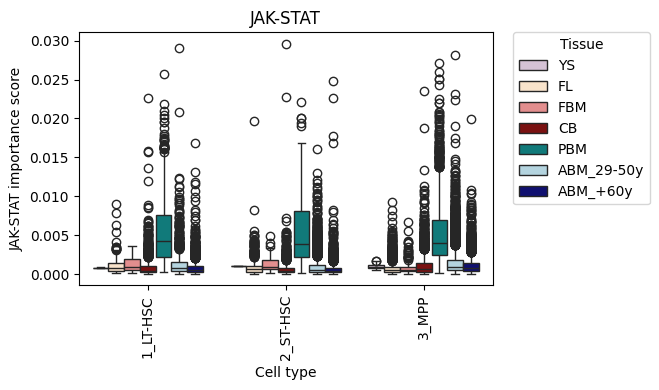

In [23]:
# JAK/STAT: LT-HSC, ST-HSC, MPP, LMPP, CLP, GMP
make_barplot(pert_data, 
             gp = 'JAK-STAT', 
             cell_types = ['1_LT-HSC', '2_ST-HSC', '3_MPP', 
                           #'4_MEMP', '9_LMPP', '10_CLP', '21_GMP',
                          ], 
             fig_size = (8,4),
             drop_ys = False,
             save = 'jak_stat_pbm.pdf'
             
            )

/software/cellgen/team292/mm58/venvs/lightning2/lib/python3.10/site-packages/anndata/_core/anndata.py:1754: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  utils.warn_names_duplicates("obs")
/tmp/ipykernel_403396/3424009345.py:6: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
  adata.obs['tissue'] = adata.obs['tissue'].cat.remove_unused_categories()
/software/cellgen/team292/mm58/venvs/lightning2/lib/python3.10/site-packages/anndata/_core/anndata.py:1754: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  utils.warn_names_duplicates("obs")
/software/cellgen/team292/mm58/venvs/lightning2/lib/python3.10/site-packages/anndata/_core/anndata.py:1754: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  utils.warn_names_duplicates("obs")


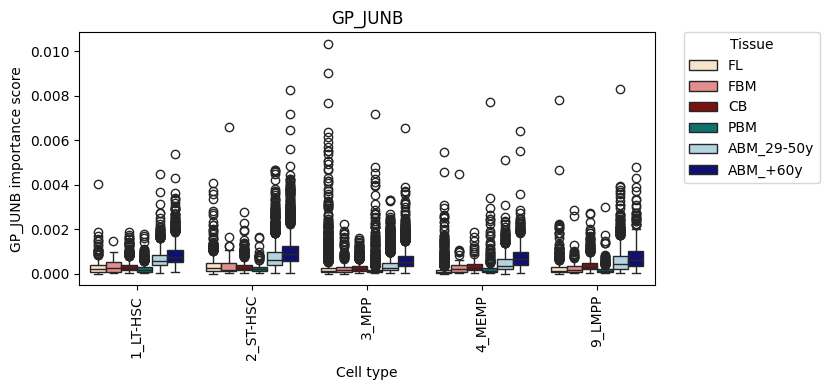

In [24]:
# GP_JUNB: LT-HSC, ST-HSC, MPP, MEMP, LMPP
make_barplot(pert_data, 
             gp = 'GP_JUNB', 
             cell_types = ['1_LT-HSC', '2_ST-HSC', '3_MPP', '4_MEMP',
                           '9_LMPP',
                          ], 
             fig_size = (10,4),
             save = 'junb.pdf'
            )

In [26]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from matplotlib.cm import ScalarMappable
from matplotlib.colors import Normalize
from matplotlib.ticker import FuncFormatter


def plot_logfold_bar_with_pval_colorbar(df,  title_ct, top_n=10,color_map = 'Blues', save_to = None):
    """
    Plots a horizontal bar plot with bars colored by -log10(pvals_adj).
    The colorbar directly reflects -log10(pvals_adj) values.
    
    Parameters:
    - df: pandas DataFrame with columns: names, scores, logfoldchanges, pvals, pvals_adj
    - top_n: number of top entries by absolute log fold change
    """
    # Prepare data
    df_sorted = df.reindex(df['logfoldchanges'].sort_values(ascending=False).index)
    df_top = df_sorted.head(top_n).copy()
    df_top['-log10(pvals_adj)'] = -np.log10(df_top['pvals_adj'].replace(0, np.nextafter(0, 1)))

    # Color mapping
    cmap = plt.get_cmap(color_map)
    norm = Normalize(vmin=df_top['-log10(pvals_adj)'].min(), vmax=df_top['-log10(pvals_adj)'].max())
    colors = cmap(norm(df_top['-log10(pvals_adj)']))

    # Plot
    fig, ax = plt.subplots(figsize=(5, 0.15 * top_n + 2))
    ax.barh(
        y=df_top['names'],
        width=df_top['logfoldchanges'],
        color=colors,
        edgecolor='black'
    )
    
    ax.invert_yaxis()
    ax.set_xlabel("Log Fold Change")
    ax.set_ylabel("")
    ax.set_title(f"Top {top_n} GP in {title_ct} \nby log fold change")

    # Add colorbar reflecting -log10(pvals_adj)
    sm = ScalarMappable(cmap=cmap, norm=norm)
    sm.set_array([])
    cbar = fig.colorbar(sm, ax=ax)
    cbar.set_label('-log10(Adjusted p-value)', rotation=270, labelpad=15)

    plt.tight_layout()
    
    if save_to:
        plt.savefig(save_to)
    
    plt.show()

# Example usage:
# plot_logfold_bar_with_log10pval_colorbar(df, top_n=20)


# Example usage:
# plot_logfold_bar_with_pval_colorbar(df, top_n=20)


In [27]:
hspc = pert_data[pert_data.obs['cell_type'].isin(
    ['1_LT-HSC', '2_ST-HSC', '3_MPP', '4_MEMP',
                           '9_LMPP', '10_CLP', '21_GMP',
                          ]
)]

In [28]:
sc.tl.rank_genes_groups(hspc, groupby = 'tissue')

/software/cellgen/team292/mm58/venvs/lightning2/lib/python3.10/site-packages/scanpy/tools/_rank_genes_groups.py:645: ImplicitModificationWarning: Trying to modify attribute `._uns` of view, initializing view as actual.
  adata.uns[key_added] = {}
/software/cellgen/team292/mm58/venvs/lightning2/lib/python3.10/site-packages/anndata/_core/anndata.py:1754: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  utils.warn_names_duplicates("obs")
/software/cellgen/team292/mm58/venvs/lightning2/lib/python3.10/site-packages/anndata/_core/anndata.py:1754: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  utils.warn_names_duplicates("obs")


In [29]:
dfi = sc.get.rank_genes_groups_df(hspc, group = 'PBM')

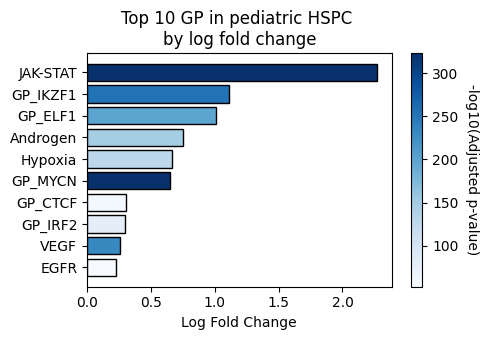

In [31]:
plot_logfold_bar_with_pval_colorbar(dfi.sort_values(by = 'logfoldchanges', ascending = False),
                                    title_ct = 'pediatric HSPC',
                                    color_map = 'Blues', 
                                    save_to = 'pbm.pdf'
                                   )

# IKZF1 without yolk sac

In [34]:
def make_barplot(pert_data, gp, cell_types, drop_ys=True, fig_size = (10, 5), save = None):
    adata = pert_data[pert_data.obs['cell_type'].isin(cell_types)].copy()
    
    if drop_ys:
        adata = adata[adata.obs['tissue'] != 'YS']
        adata.obs['tissue'] = adata.obs['tissue'].cat.remove_unused_categories()
        colors = ['bisque', 'lightcoral', 
                  #'darkred',
                  "teal", 
                  'lightblue', 'navy']
    else:
        colors = ['thistle', # YS
                  'bisque', # FL
                  'lightcoral', # FBM
                  #'darkred', # CB
                  "darkcyan", # pediatric
                  'lightblue', # adult BM
                  'navy', # aged BM 
                 ]

    adata.obs[gp] = adata[:, adata.var.index == gp].X.toarray().flatten()

    plt.figure(figsize=fig_size)
    ax = sns.boxplot(
        data=adata.obs,
        y=gp,
        x="cell_type",
        hue="tissue",
        order=adata.obs['cell_type'].cat.categories,
        palette=colors
    )

    plt.xticks(rotation=90)
    plt.xlabel("Cell type")
    plt.ylabel(f"{gp} importance score")
    plt.title(gp)

    plt.legend(
        title="Tissue",
        bbox_to_anchor=(1.05, 1),
        loc='upper left',
        borderaxespad=0.
    )

    plt.tight_layout(rect=[0, 0, 0.85, 1])  
    
    if save:
        plt.savefig(save)

    plt.show()


/software/cellgen/team292/mm58/venvs/lightning2/lib/python3.10/site-packages/anndata/_core/anndata.py:1754: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  utils.warn_names_duplicates("obs")


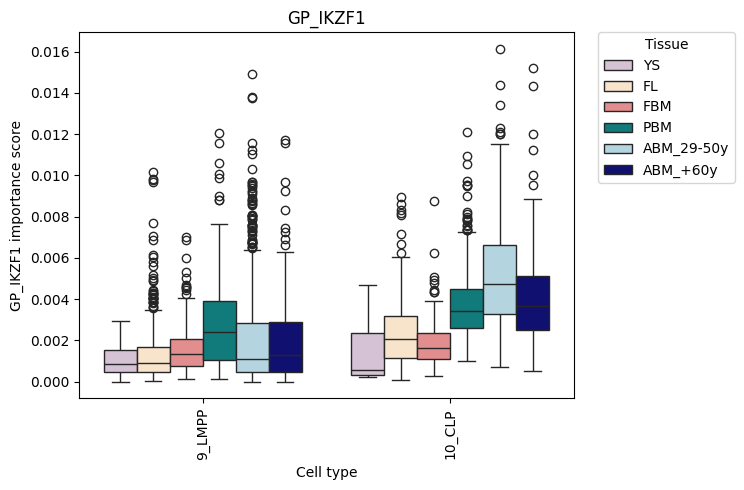

In [35]:
# GP_IKZF1: LMPP, CLP
make_barplot(pert_data[pert_data.obs['tissue'] != 'CB'], 
             gp = 'GP_IKZF1', 
             cell_types = ['9_LMPP', '10_CLP'], 
             fig_size = (9,5),
             drop_ys = False,
             save = 'ikzf1_no_cb.pdf'
            )